# Day 5 of Machine Learning Journey
### Linear Regression using Scikit-Learn

**Author:** Aneesh  
**Day:** 5   
**Topic:** Gradient Decent Algorithm


## Overview

In this module, I will focus on building an intuitive understanding of the **Gradient Descent Algorithm** using a randomly generated dataset.

I will create a synthetic dataset with multiple input features and a target variable. This will allow me to clearly observe how Gradient Descent iteratively updates model parameters (weights and bias) to minimize the loss function.

The main objective is to understand how Multiple Linear Regression learns from data through optimization, and how the model gradually converges towards the best-fitting parameters by following the negative gradient of the cost function.

I will implement Gradient Descent from scratch, visualize the loss reduction over iterations, and analyze how different learning rates affect convergence and model performance.


### Dataset Description

###Installing Libraries


In [86]:
pip install numpy pandas matplotlib scikit-learn

###Importing Libraries

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression   # to generate random dataset


### Making Random Dataset


In [88]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

### Basic Information

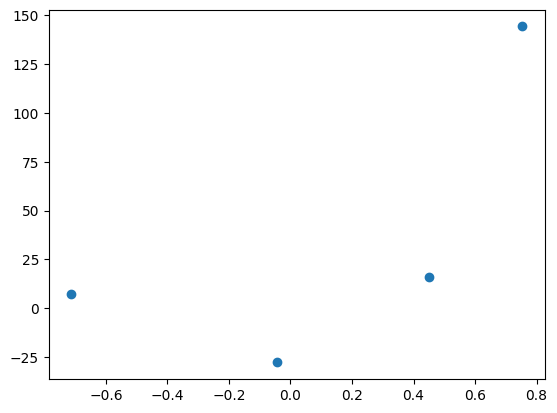

In [89]:
plt.scatter(X,y)

In [90]:
# Importing required libraries:
# LinearRegression -> to create and train the linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score                 # For R2 score

In [91]:
model = LinearRegression()
model.fit(X,y)           # training the ml model

model.predict([[0.04]])  # predicting the output


array([29.29365831])

In [92]:
weight = model.coef_
print(weight)

intercept = model.intercept_
print(intercept)

[78.35063668]
26.15963284313262


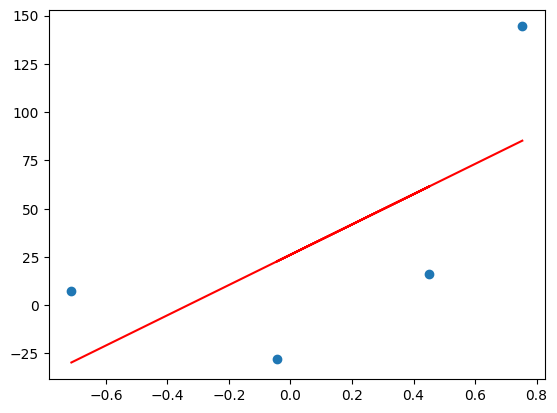

In [93]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red')   # this is the regression line between X and predicted value of X .

###Applying Gradient Decent


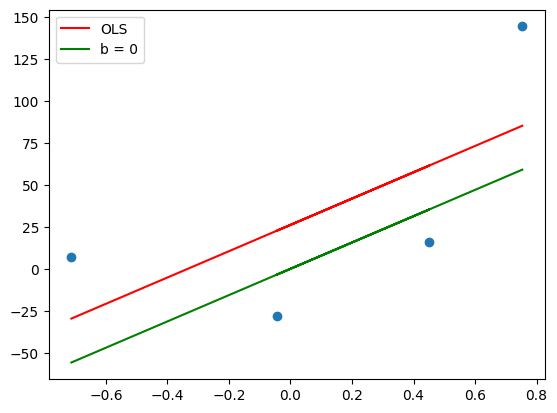

In [94]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 0).reshape(4)

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b = 0')
plt.legend()
plt.show()


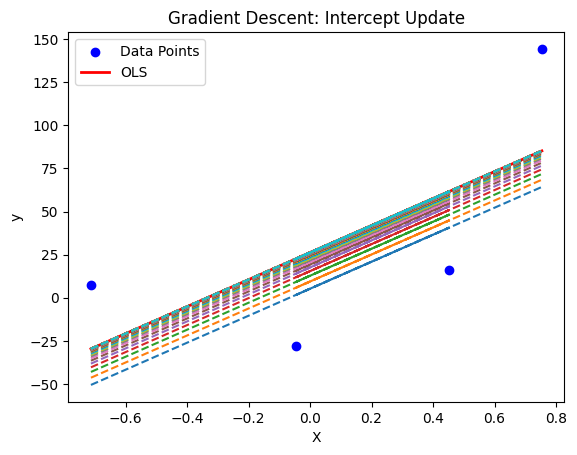

In [98]:
# Gradient Descent: updating only intercept b (m fixed)

m = 78.35
b = 0
lr = 0.1
iterations = 100

plt.scatter(X, y, color='blue', label='Data Points')

# Plot OLS line (optimal regression line)
plt.plot(X, model.predict(X), color='red', linewidth=2, label='OLS')

for i in range(iterations):

    # Compute predictions with current b
    y_pred = (m * X) + b

    # Compute gradient wrt b
    error = y - y_pred.reshape(-1)
    gradient_b = (-2 * np.sum(error)) / len(X)

    # Update b
    b = b - lr * gradient_b

    # Plot line for this iteration
    plt.plot(X, m*X + b, linestyle='--')

plt.title("Gradient Descent: Intercept Update")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


###Creating my own class for Gradient Decent

In [131]:
class GDReg:

  def __init__(self,lr,epoch):
    self.m =  100    #fixing with any value
    self.b = -120    # just starting with any value
    self.epoch = epoch
    self.lr = lr

  def fit(self,X,y):
    X = X.ravel()
    for i in range(self.epoch):
      y_pred = self.m * X + self.b
      error = y - y_pred
      gradient_b = (-2 * np.sum(error)) / len(X)
      gradient_m = (-2 * np.sum(error * X)) / len(X)
      self.b = self.b - self.lr*(gradient_b)
      self.m = self.m - self.lr*(gradient_m)

    print(self.b)
    print(self.m)

  def predict(self ,X):
    return self.m * X + self.b



In [135]:
gd = GDReg(0.01,5000)
gd.fit(X,y)

gd.predict(X)

26.1596328431321
78.35063667947806


array([[-29.65662909],
       [ 61.55941724],
       [ 22.67278832],
       [ 85.21770852]])